# 🏦 AI-Powered Smart Loan Approval Prediction System

## 📈 Predicting Loan Eligibility using Machine Learning & Data Analytics

## 🎯 Project Overview

This project aims to predict whether a loan application should be **Approved** or **Rejected** using Machine Learning techniques.

The notebook covers the complete Machine Learning workflow, including:

✅ Data Collection

✅ Data Cleaning

✅ Exploratory Data Analysis (EDA)

✅ Data Preprocessing

✅ Feature Engineering

✅ Machine Learning Model Development

✅ Model Evaluation

✅ Loan Prediction

---

### 🛠️ Technologies Used

- 🐍 Python
- ☁️ Google Colab
- 🐼 Pandas
- 🔢 NumPy
- 📊 Matplotlib
- 🎨 Seaborn
- 🤖 Scikit-Learn


# 📚 Business Problem

Financial institutions receive thousands of loan applications every day.

Approving an ineligible applicant may lead to financial loss, while rejecting an eligible customer affects customer satisfaction.

This project uses Machine Learning to analyze applicant information and predict whether a loan should be approved.

🎯 Goal:
Build an intelligent prediction system that assists banks in making faster and more accurate loan approval decisions.

# 🚀 Machine Learning Workflow

📂 Dataset Collection

⬇️

🧹 Data Cleaning

⬇️

📊 Exploratory Data Analysis

⬇️

⚙️ Feature Engineering

⬇️

✂️ Train-Test Split

⬇️

🤖 Model Training

⬇️

📈 Model Evaluation

⬇️

🎯 Loan Approval Prediction

In [2]:


import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [4]:


df = pd.read_csv("train.csv")

print("Dataset Loaded Successfully ✅")

Dataset Loaded Successfully ✅


In [5]:
df.head(10)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
5,LP001011,Male,Yes,2,Graduate,Yes,5417,4196.0,267.0,360.0,1.0,Urban,Y
6,LP001013,Male,Yes,0,Not Graduate,No,2333,1516.0,95.0,360.0,1.0,Urban,Y
7,LP001014,Male,Yes,3+,Graduate,No,3036,2504.0,158.0,360.0,0.0,Semiurban,N
8,LP001018,Male,Yes,2,Graduate,No,4006,1526.0,168.0,360.0,1.0,Urban,Y
9,LP001020,Male,Yes,1,Graduate,No,12841,10968.0,349.0,360.0,1.0,Semiurban,N


In [6]:
print("Rows :",df.shape[0])

print("Columns :",df.shape[1])

print("\n")

df.shape

Rows : 614
Columns : 13




(614, 13)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ApplicantIncome,614.0,5403.459283,6109.041673,150.0,2877.5,3812.5,5795.00,81000.0
CoapplicantIncome,614.0,1621.245798,2926.248369,0.0,0.0,1188.5,2297.25,41667.0
LoanAmount,592.0,146.412162,85.587325,9.0,100.0,128.0,168.00,700.0
Loan_Amount_Term,600.0,342.000000,65.120410,12.0,360.0,360.0,360.00,480.0
Credit_History,564.0,0.842199,0.364878,0.0,1.0,1.0,1.00,1.0


In [9]:
df.isnull().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


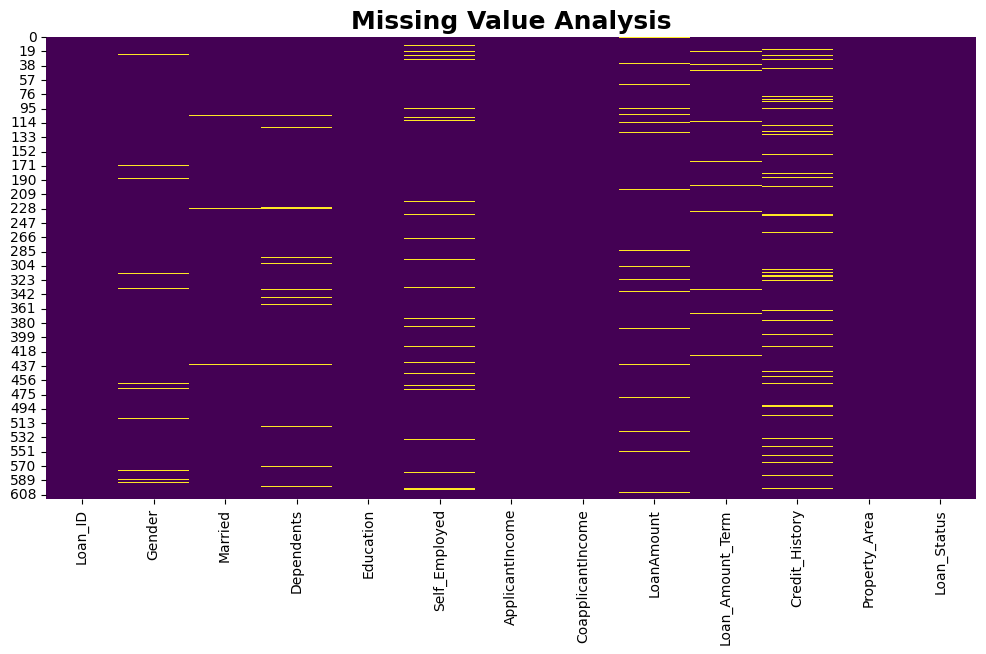

In [10]:
plt.figure(figsize=(12,6))

sns.heatmap(
    df.isnull(),
    cmap="viridis",
    cbar=False
)

plt.title("Missing Value Analysis",fontsize=18,fontweight="bold")

plt.show()

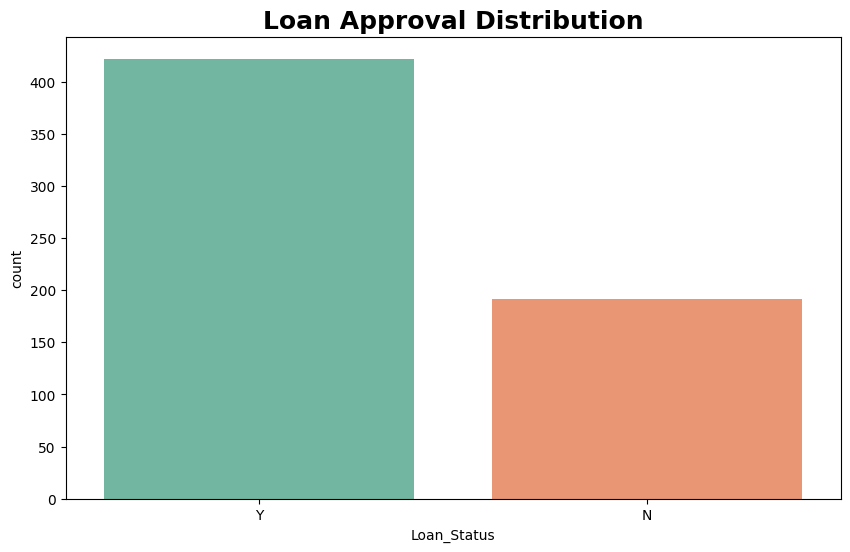

In [11]:
plt.figure(figsize=(10,6))

sns.countplot(
    x="Loan_Status",
    data=df,
    palette="Set2"
)

plt.title("Loan Approval Distribution",fontsize=18,fontweight="bold")

plt.show()

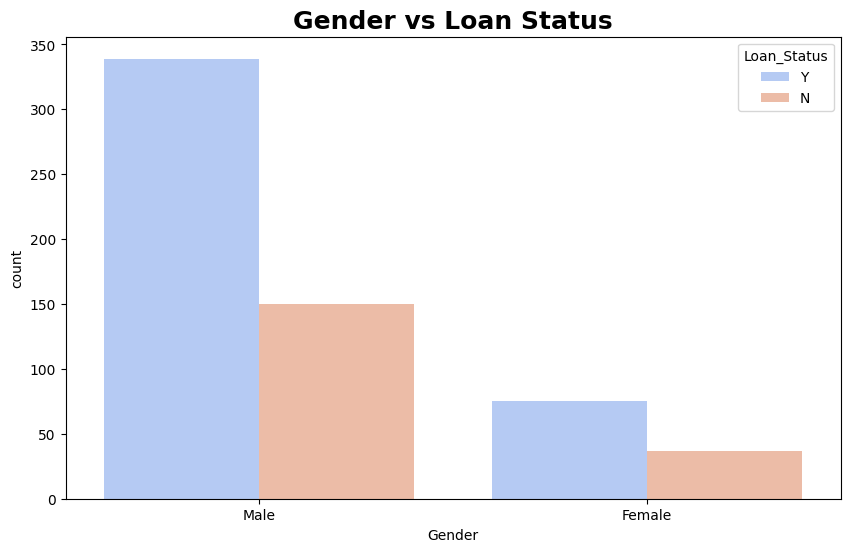

In [12]:
plt.figure(figsize=(10,6))

sns.countplot(
    x="Gender",
    hue="Loan_Status",
    data=df,
    palette="coolwarm"
)

plt.title("Gender vs Loan Status",fontsize=18,fontweight="bold")

plt.show()

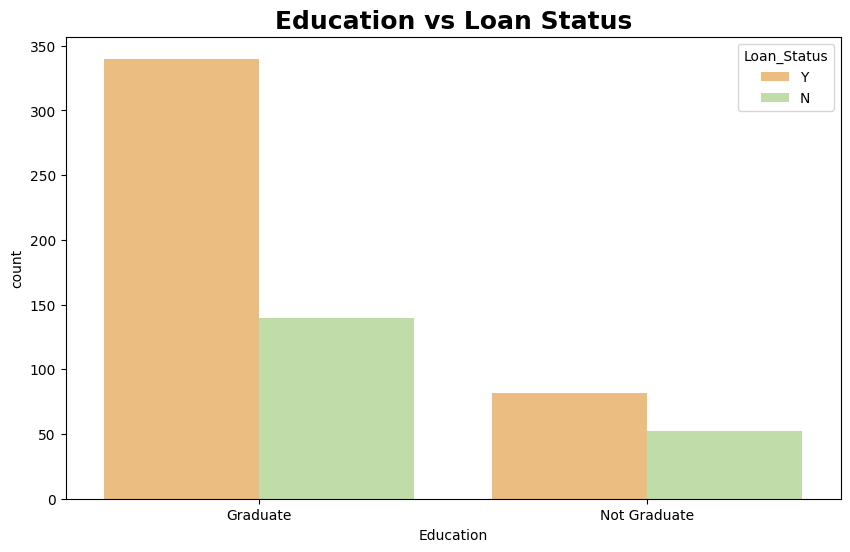

In [13]:
plt.figure(figsize=(10,6))

sns.countplot(
    x="Education",
    hue="Loan_Status",
    data=df,
    palette="Spectral"
)

plt.title("Education vs Loan Status",fontsize=18,fontweight="bold")

plt.show()

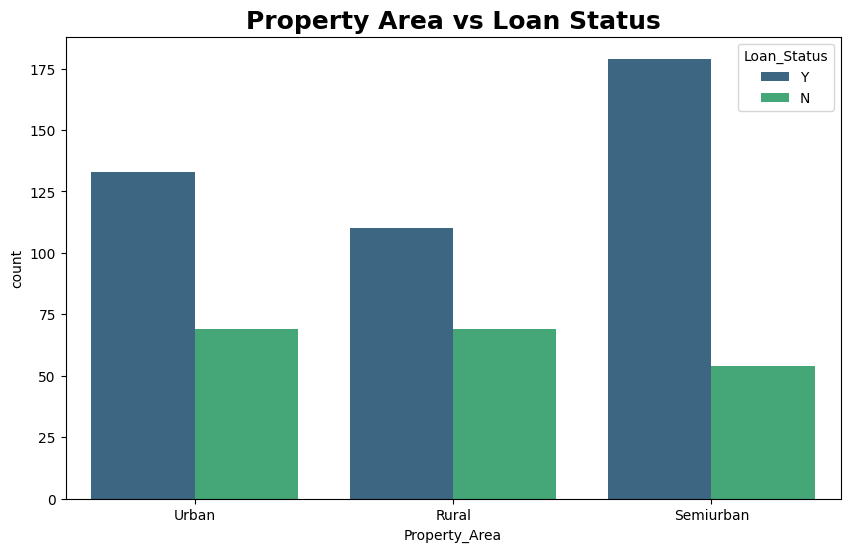

In [14]:
plt.figure(figsize=(10,6))

sns.countplot(
    x="Property_Area",
    hue="Loan_Status",
    data=df,
    palette="viridis"
)

plt.title("Property Area vs Loan Status",fontsize=18,fontweight="bold")

plt.show()

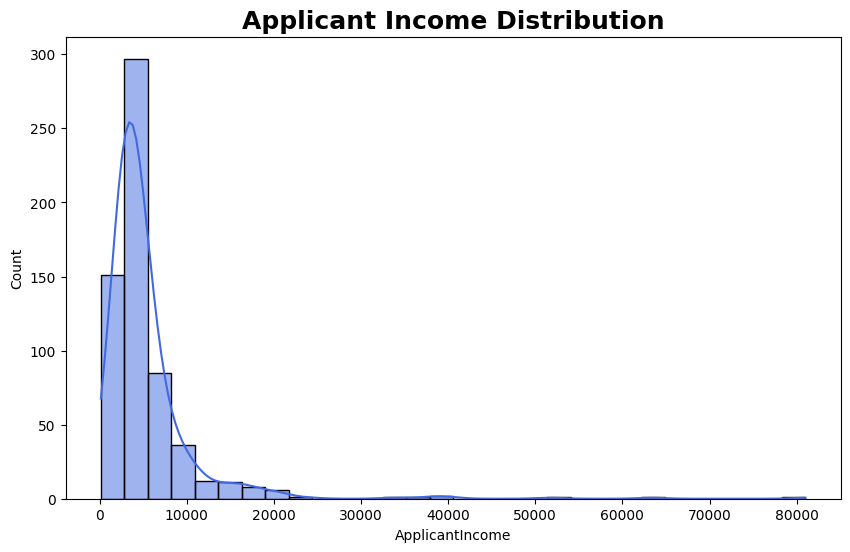

In [15]:
plt.figure(figsize=(10,6))

sns.histplot(
    df["ApplicantIncome"],
    kde=True,
    bins=30,
    color="royalblue"
)

plt.title("Applicant Income Distribution",fontsize=18,fontweight="bold")

plt.show()

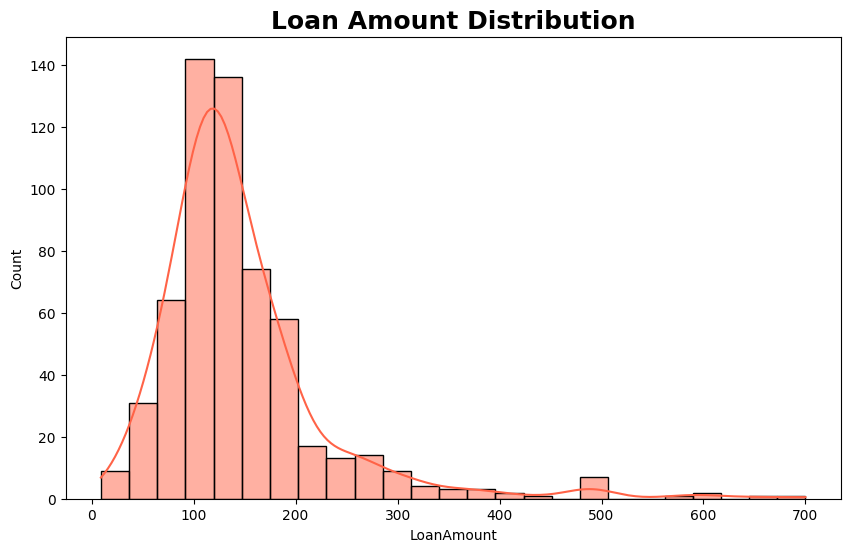

In [16]:
plt.figure(figsize=(10,6))

sns.histplot(
    df["LoanAmount"],
    kde=True,
    bins=25,
    color="tomato"
)

plt.title("Loan Amount Distribution",fontsize=18,fontweight="bold")

plt.show()

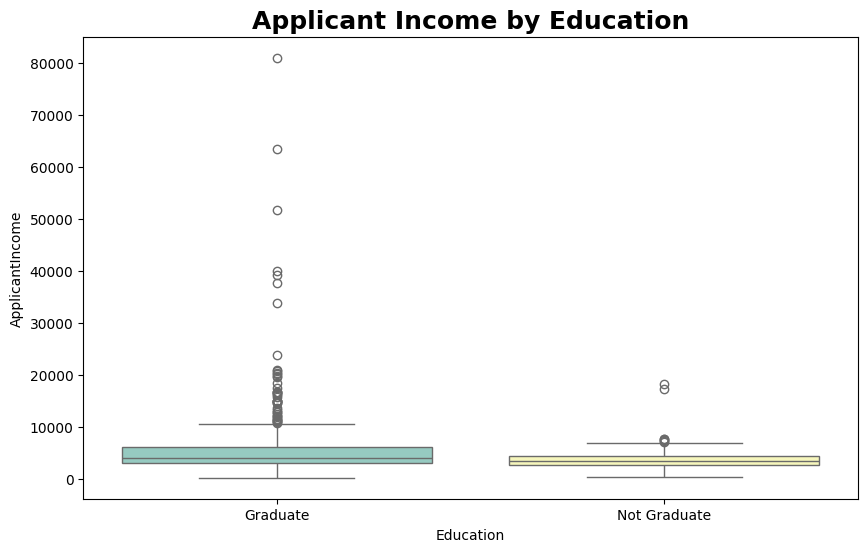

In [17]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x="Education",
    y="ApplicantIncome",
    data=df,
    palette="Set3"
)

plt.title("Applicant Income by Education",fontsize=18,fontweight="bold")

plt.show()

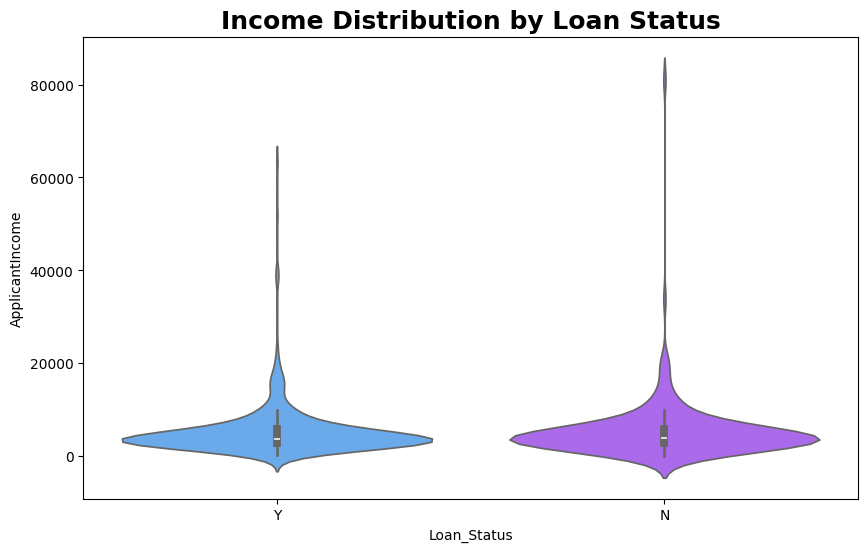

In [18]:
plt.figure(figsize=(10,6))

sns.violinplot(
    x="Loan_Status",
    y="ApplicantIncome",
    data=df,
    palette="cool"
)

plt.title("Income Distribution by Loan Status",fontsize=18,fontweight="bold")

plt.show()

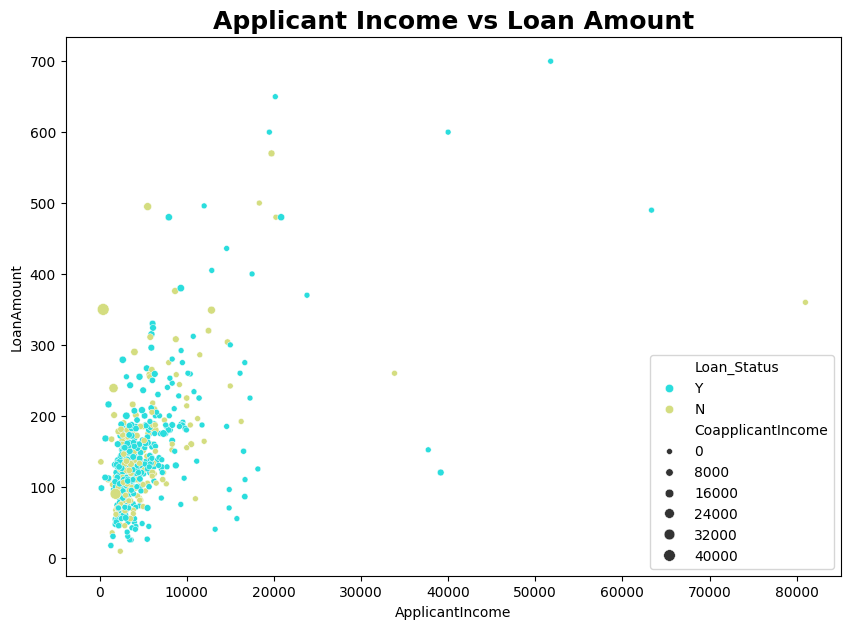

In [19]:
plt.figure(figsize=(10,7))

sns.scatterplot(
    x="ApplicantIncome",
    y="LoanAmount",
    hue="Loan_Status",
    size="CoapplicantIncome",
    palette="rainbow",
    data=df
)

plt.title("Applicant Income vs Loan Amount",fontsize=18,fontweight="bold")

plt.show()

# ⚙️ Data Preprocessing & Feature Engineering

Before training Machine Learning models, the dataset needs to be cleaned and transformed.

In this section we will:

✅ Handle Missing Values

✅ Encode Categorical Features

✅ Prepare Features & Target

✅ Scale Numerical Features

✅ Split Dataset for Training & Testing

In [20]:
print("Missing Values\n")

df.isnull().sum()

Missing Values



,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


In [21]:
df["Gender"].fillna(df["Gender"].mode()[0], inplace=True)

df["Married"].fillna(df["Married"].mode()[0], inplace=True)

df["Dependents"].fillna(df["Dependents"].mode()[0], inplace=True)

df["Self_Employed"].fillna(df["Self_Employed"].mode()[0], inplace=True)

df["LoanAmount"].fillna(df["LoanAmount"].median(), inplace=True)

df["Loan_Amount_Term"].fillna(df["Loan_Amount_Term"].mode()[0], inplace=True)

df["Credit_History"].fillna(df["Credit_History"].mode()[0], inplace=True)

In [22]:
df.isnull().sum()

,0
Loan_ID,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0


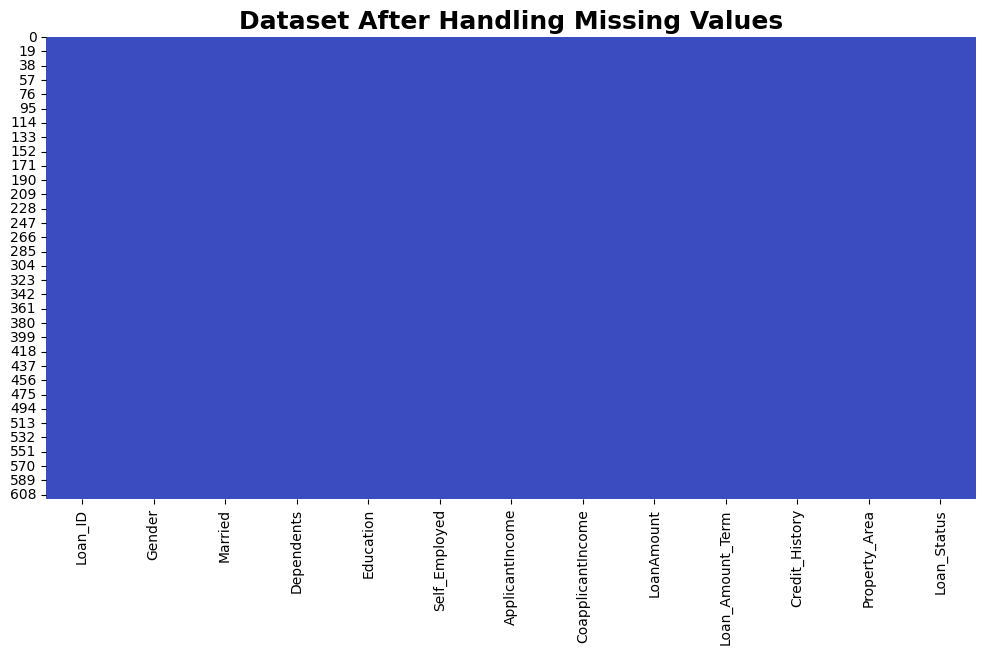

In [23]:
plt.figure(figsize=(12,6))

sns.heatmap(
    df.isnull(),
    cmap="coolwarm",
    cbar=False
)

plt.title(
    "Dataset After Handling Missing Values",
    fontsize=18,
    fontweight="bold"
)

plt.show()

In [24]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [25]:
df.drop("Loan_ID",axis=1,inplace=True)

In [26]:
df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,Y
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [27]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

categorical_columns = [
    "Gender",
    "Married",
    "Dependents",
    "Education",
    "Self_Employed",
    "Property_Area",
    "Loan_Status"
]

for column in categorical_columns:

    df[column] = encoder.fit_transform(df[column])

In [28]:
df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,1,0,0,0,0,5849,0.0,128.0,360.0,1.0,2,1
1,1,1,1,0,0,4583,1508.0,128.0,360.0,1.0,0,0
2,1,1,0,0,1,3000,0.0,66.0,360.0,1.0,2,1
3,1,1,0,1,0,2583,2358.0,120.0,360.0,1.0,2,1
4,1,0,0,0,0,6000,0.0,141.0,360.0,1.0,2,1


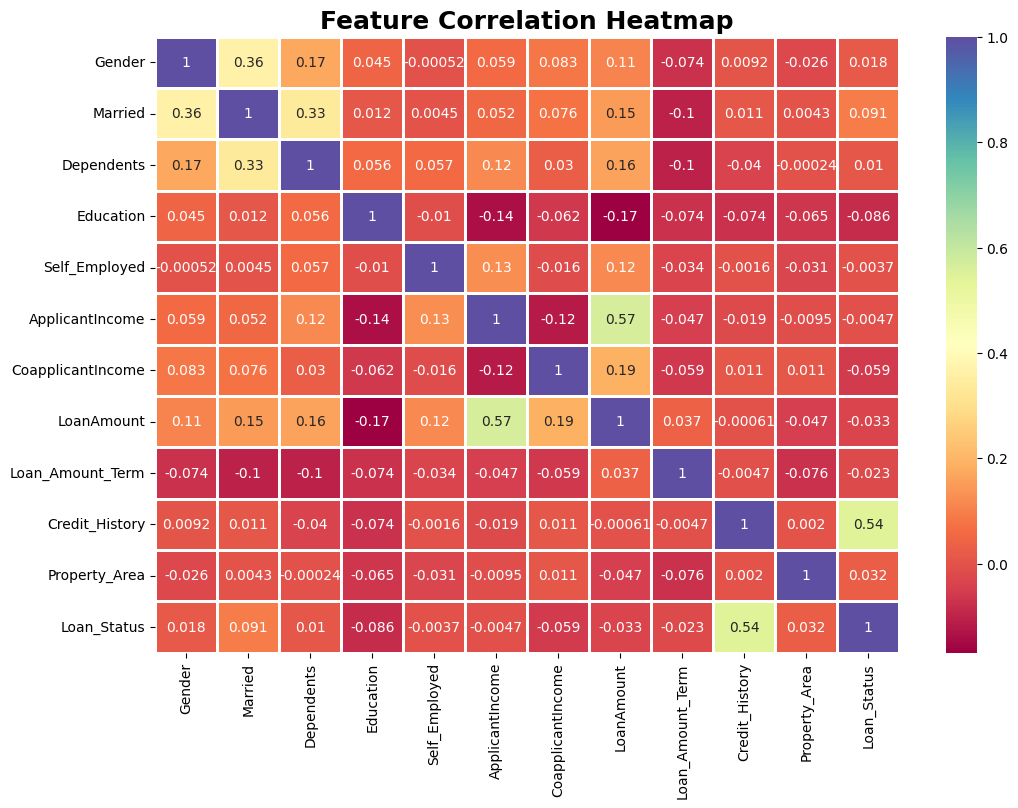

In [29]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="Spectral",
    linewidths=1
)

plt.title(
    "Feature Correlation Heatmap",
    fontsize=18,
    fontweight="bold"
)

plt.show()

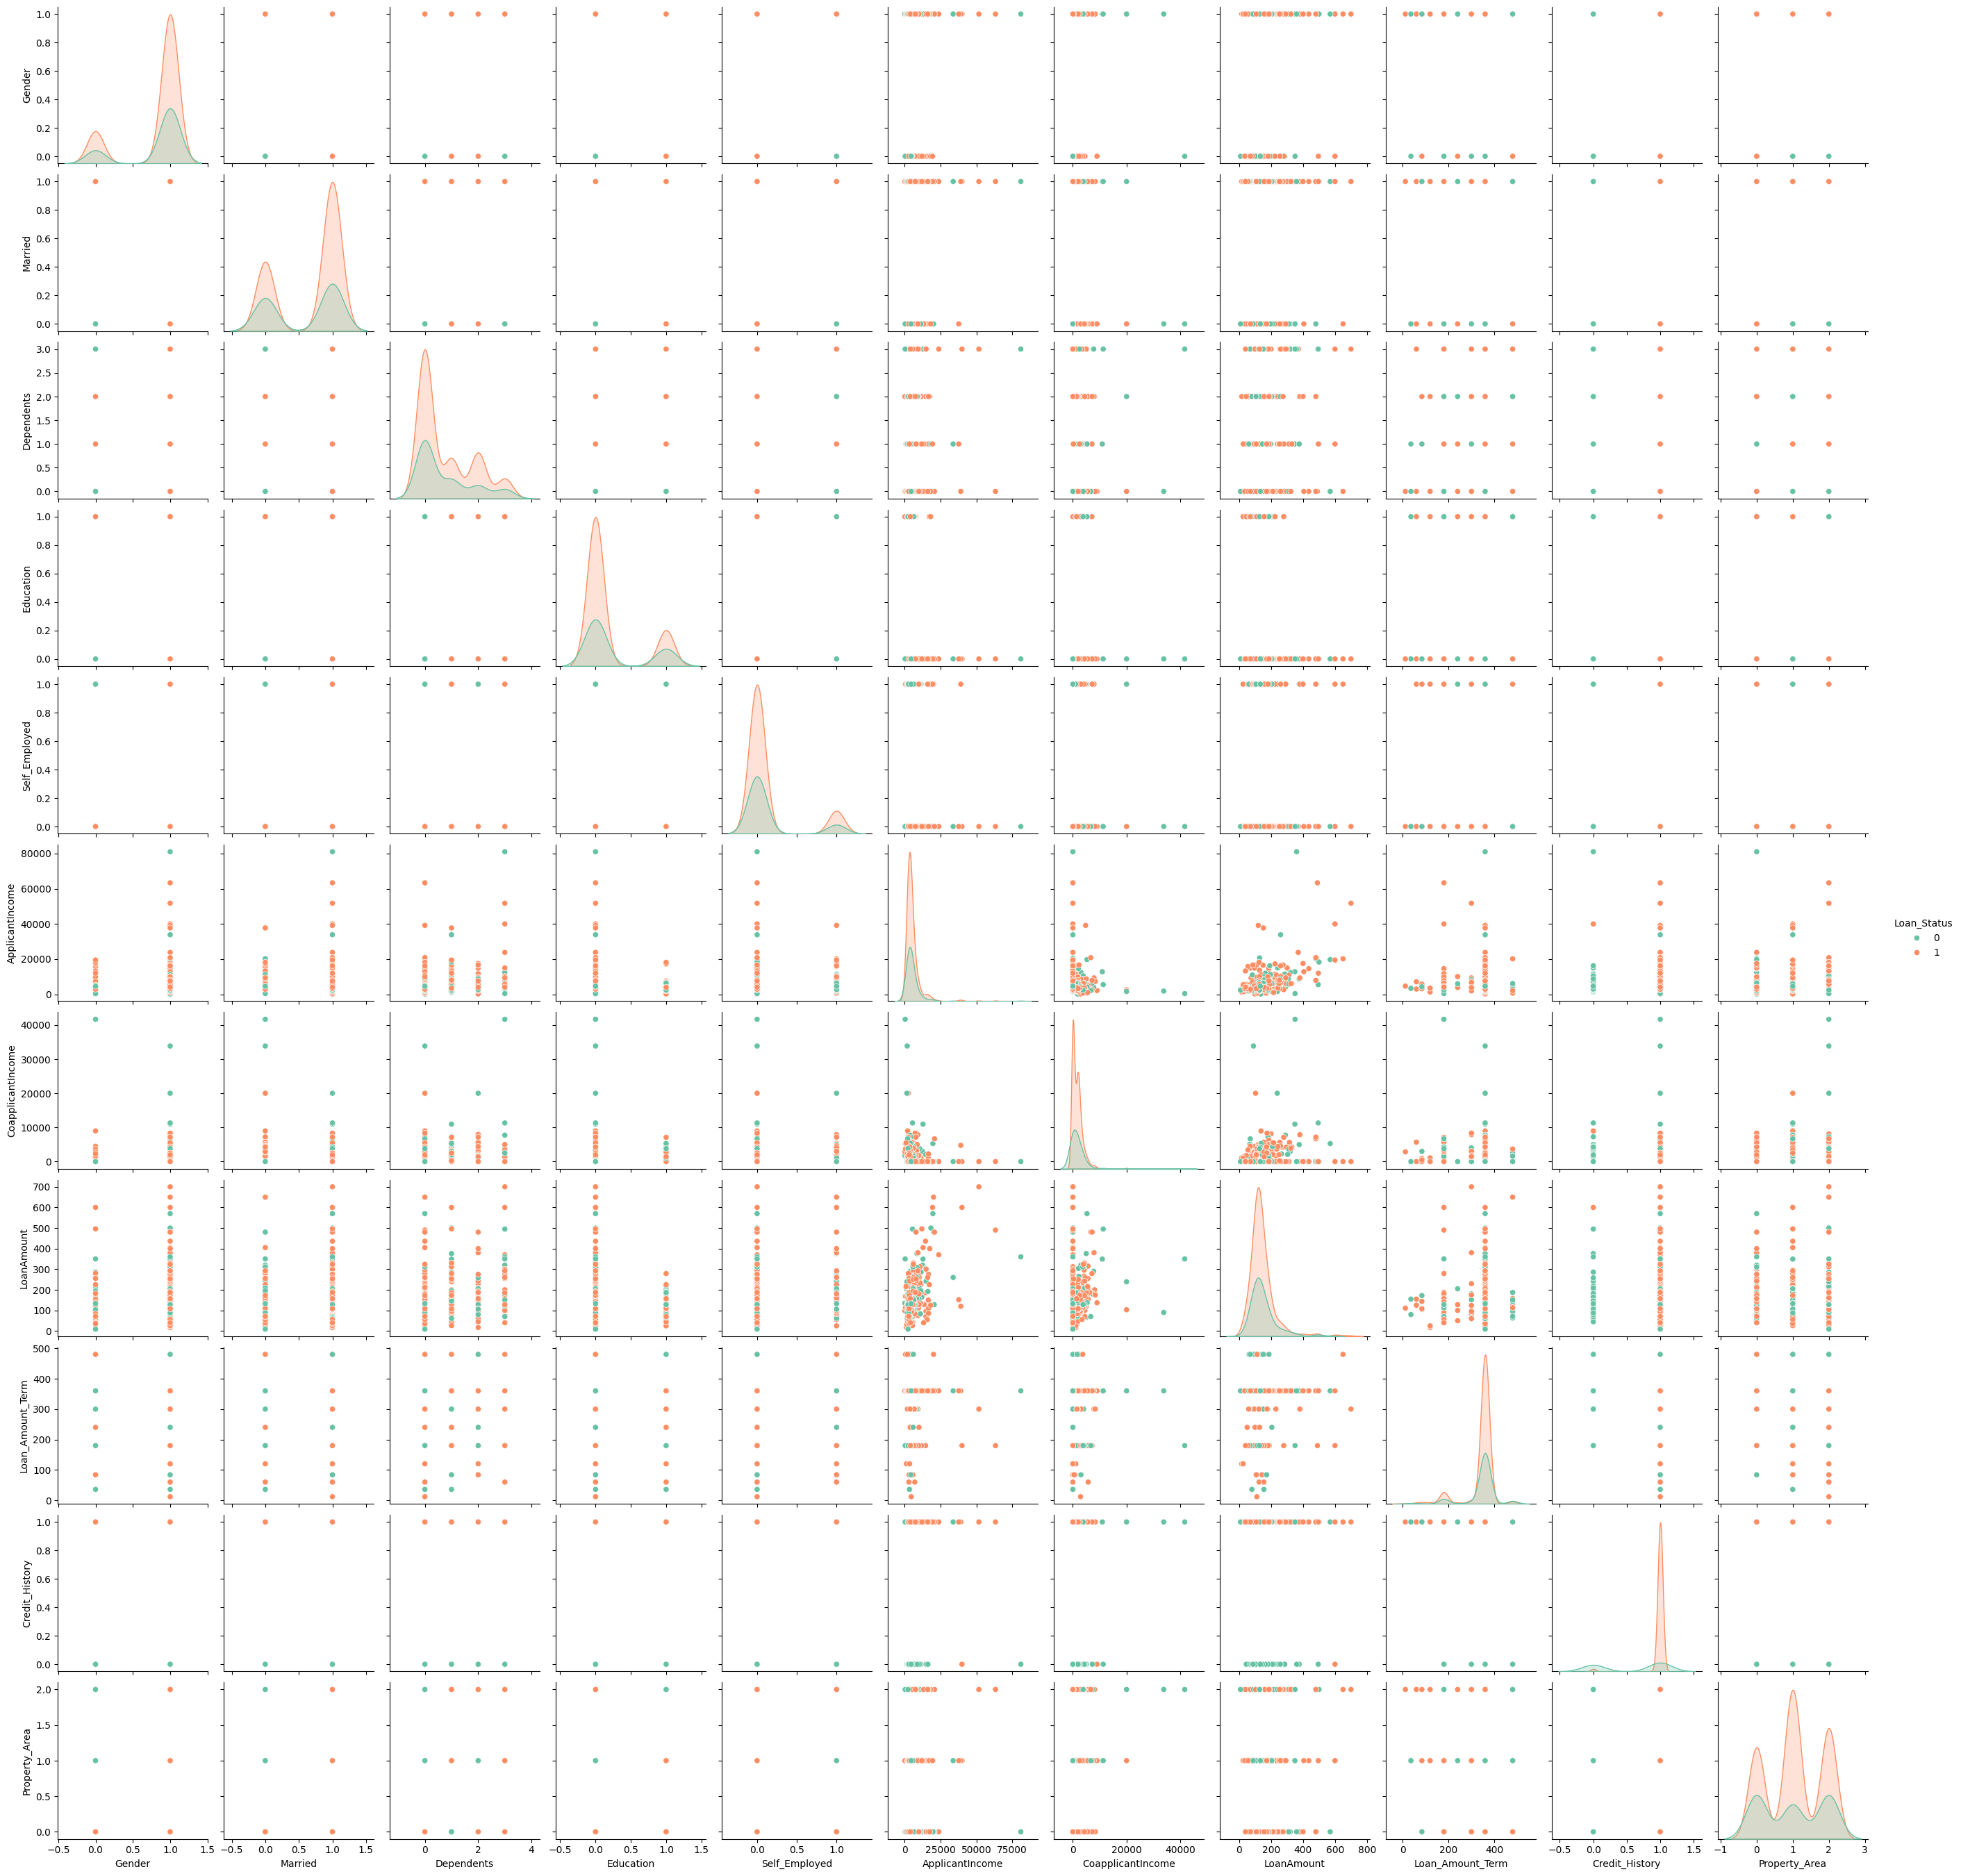

In [30]:
sns.pairplot(
    df,
    hue="Loan_Status",
    palette="Set2"
)

plt.show()

<Figure size 1000x600 with 0 Axes>

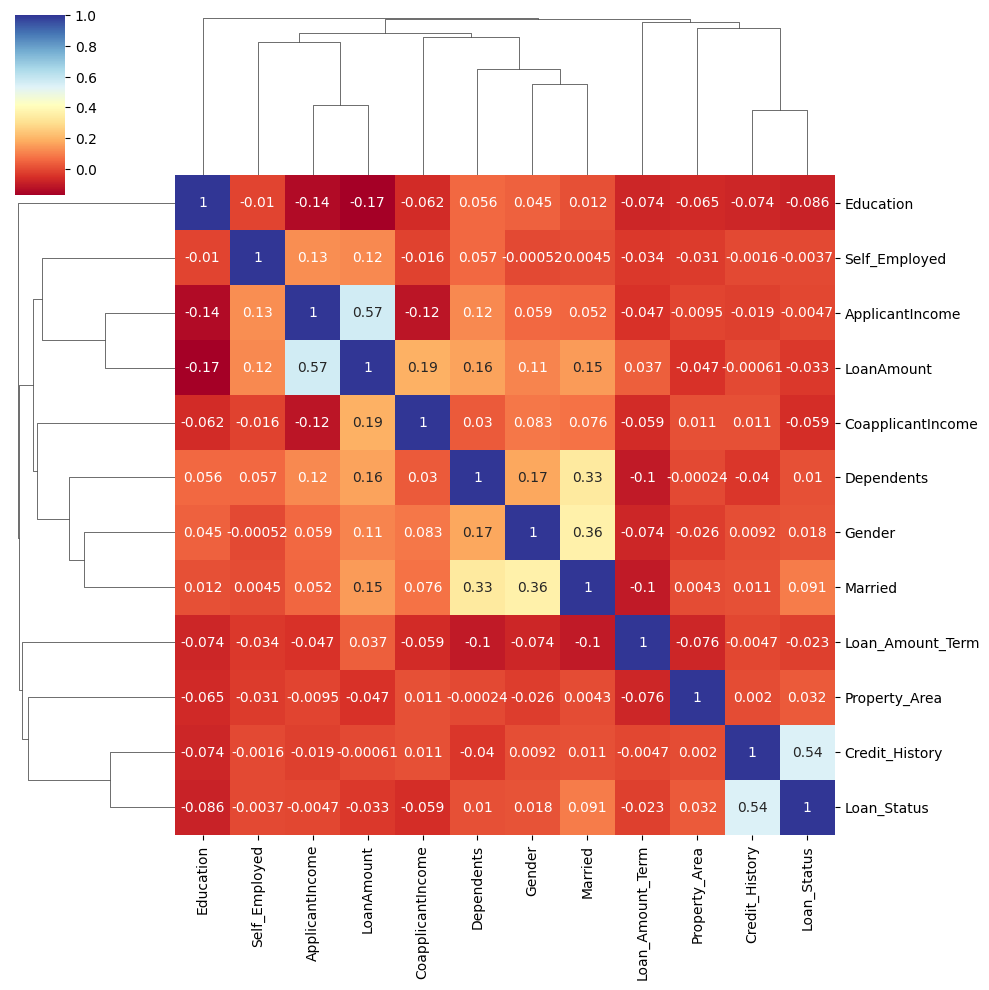

In [31]:
plt.figure(figsize=(10,6))

sns.clustermap(
    df.corr(),
    cmap="RdYlBu",
    annot=True,
    figsize=(10,10)
)

In [32]:
X = df.drop("Loan_Status",axis=1)

y = df["Loan_Status"]

print(X.shape)

print(y.shape)

(614, 11)
(614,)


In [33]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [34]:
print("Training Data :",X_train.shape)

print("Testing Data :",X_test.shape)

Training Data : (491, 11)
Testing Data : (123, 11)


In [35]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [36]:
print("Feature Scaling Completed Successfully ✅")

Feature Scaling Completed Successfully ✅


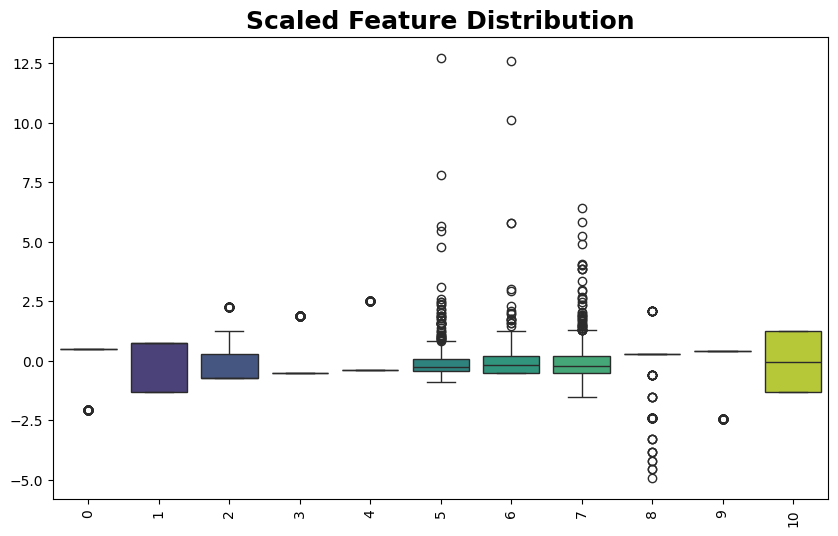

In [37]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=pd.DataFrame(X_train),
    palette="viridis"
)

plt.title(
    "Scaled Feature Distribution",
    fontsize=18,
    fontweight="bold"
)

plt.xticks(rotation=90)

plt.show()

# ✅ Data Preprocessing Completed Successfully

The dataset has now been:

✔ Cleaned

✔ Missing Values Handled

✔ Encoded

✔ Scaled

✔ Split into Training & Testing Sets

The data is now ready for Machine Learning Model Development.

# 🤖 Machine Learning Model Development

The dataset is now clean and ready for training Machine Learning models.

In this section, multiple classification algorithms are trained and compared to identify the best-performing model for loan approval prediction.

In [38]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

In [39]:
models = {

    "Logistic Regression": LogisticRegression(max_iter=1000),

    "Decision Tree": DecisionTreeClassifier(random_state=42),

    "Random Forest": RandomForestClassifier(random_state=42),

    "KNN": KNeighborsClassifier(),

    "Naive Bayes": GaussianNB(),

    "Support Vector Machine": SVC()

}

accuracy = []

for name, model in models.items():

    model.fit(X_train, y_train)

    prediction = model.predict(X_test)

    score = accuracy_score(y_test, prediction)

    accuracy.append(score)

    print(f"{name} : {score:.4f}")

Logistic Regression : 0.7886
Decision Tree : 0.6911
Random Forest : 0.7480
KNN : 0.7561
Naive Bayes : 0.7805
Support Vector Machine : 0.7886


In [40]:
comparison = pd.DataFrame({

    "Algorithm": models.keys(),

    "Accuracy": accuracy

})

comparison = comparison.sort_values(

    by="Accuracy",

    ascending=False

)

comparison

,Algorithm,Accuracy
0,Logistic Regression,0.788618
5,Support Vector Machine,0.788618
4,Naive Bayes,0.780488
3,KNN,0.756098
2,Random Forest,0.747967
1,Decision Tree,0.691057


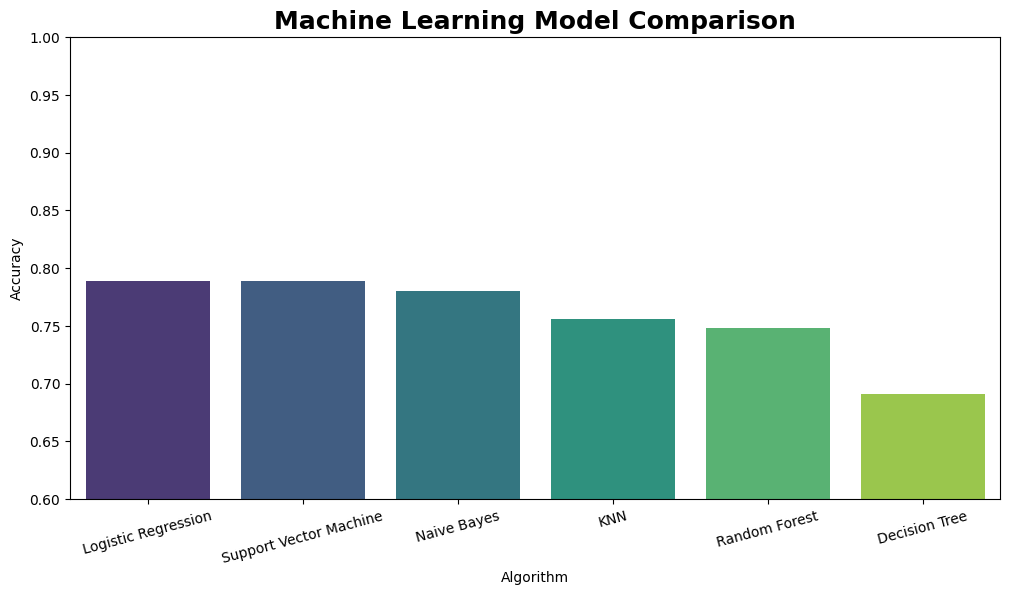

In [41]:
plt.figure(figsize=(12,6))

sns.barplot(

    x="Algorithm",

    y="Accuracy",

    data=comparison,

    palette="viridis"

)

plt.xticks(rotation=15)

plt.ylim(0.6,1)

plt.title(

    "Machine Learning Model Comparison",

    fontsize=18,

    fontweight="bold"

)

plt.show()

In [42]:
best_model_name = comparison.iloc[0]["Algorithm"]

print("🏆 Best Performing Model")

print(best_model_name)

🏆 Best Performing Model
Logistic Regression


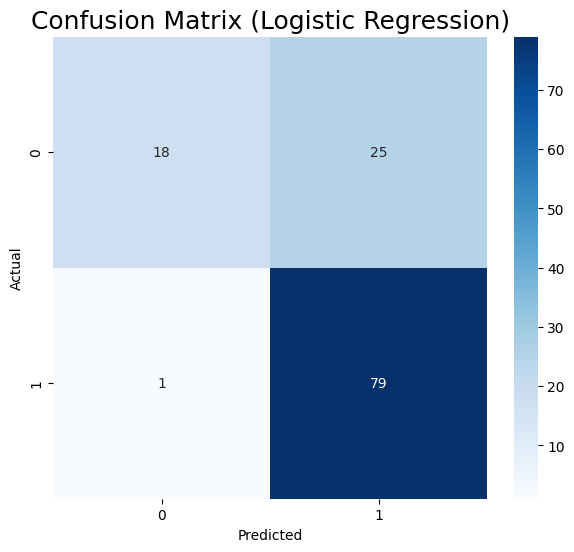

In [43]:
best_model = models[best_model_name]

prediction = best_model.predict(X_test)

cm = confusion_matrix(

    y_test,

    prediction

)

plt.figure(figsize=(7,6))

sns.heatmap(

    cm,

    annot=True,

    cmap="Blues",

    fmt="d"

)

plt.title(

    f"Confusion Matrix ({best_model_name})",

    fontsize=18

)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

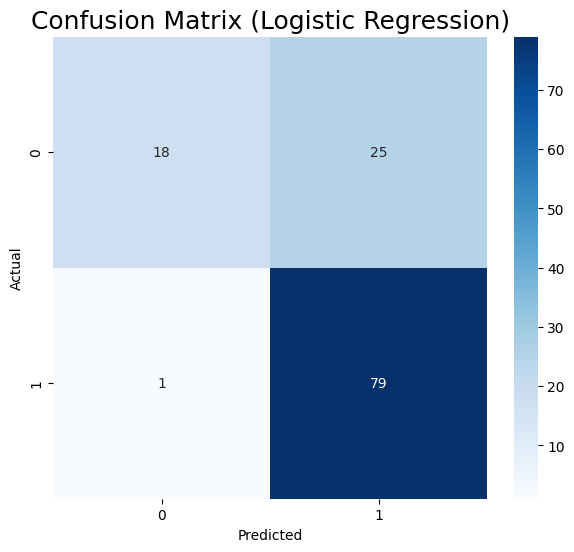

In [44]:
best_model = models[best_model_name]

prediction = best_model.predict(X_test)

cm = confusion_matrix(

    y_test,

    prediction

)

plt.figure(figsize=(7,6))

sns.heatmap(

    cm,

    annot=True,

    cmap="Blues",

    fmt="d"

)

plt.title(

    f"Confusion Matrix ({best_model_name})",

    fontsize=18

)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [45]:
print(

classification_report(

y_test,

prediction

)

)

              precision    recall  f1-score   support

           0       0.95      0.42      0.58        43
           1       0.76      0.99      0.86        80

    accuracy                           0.79       123
   macro avg       0.85      0.70      0.72       123
weighted avg       0.83      0.79      0.76       123



In [46]:
if best_model_name == "Random Forest":

    importance = pd.Series(

        best_model.feature_importances_,

        index=X.columns

    )

    importance.sort_values().plot(

        kind="barh",

        figsize=(10,6),

        color="teal"

    )

    plt.title(

        "Feature Importance",

        fontsize=18,

        fontweight="bold"

    )

    plt.show()

else:

    print("Feature Importance available for Random Forest only.")

Feature Importance available for Random Forest only.


In [47]:
sample = X.iloc[[0]]

sample_scaled = scaler.transform(sample)

prediction = best_model.predict(sample_scaled)

if prediction[0] == 1:

    print("✅ Loan Approved")

else:

    print("❌ Loan Rejected")

✅ Loan Approved


# 🏆 Project Conclusion

This project successfully demonstrated an end-to-end Machine Learning workflow for predicting loan approval.

The project included:

✅ Data Collection

✅ Data Cleaning

✅ Exploratory Data Analysis

✅ Feature Engineering

✅ Multiple Machine Learning Algorithms

✅ Model Comparison

✅ Prediction System

The comparative analysis helped identify the best-performing model, showing how Machine Learning can support smarter and faster loan approval decisions in financial institutions.

🚀 This project strengthened my understanding of Data Analytics, Machine Learning, and predictive modeling using real-world financial data.